# Ejercicio 2 - Práctica 4

El dataset `registro_temperatura365d_smn.txt` contiene las temperaturas máximas y mínimas registradas diariamente entre el 11/04/2025 y el 10/04/2026 en todas las estaciones meteorológicas de superficie pertenecientes al Servicio Meteorológico Nacional.

1. Explore la estructura del archivo. Notará que no se utiliza un delimitador particular para separar las distintas columnas sino que los distintos campos están alineados en columnas con diferente número de espacios que separan uno del otro. Por este motivo, y aprovechando que las primeras columnas son de ancho fijo, se sugiere utilizar la función `read_fwf()` de Pandas, que permite leer este tipo de archivos.

---

Sobre `read_fwf()`

La función `pd.read_fwf()` en Pandas se utiliza para leer archivos de texto que tienen columnas de ancho fijo, donde cada columna ocupa una cantidad específica de caracteres. Esta función es útil cuando los datos no están separados por delimitadores como comas o espacios, sino que están organizados en columnas de longitudes fijas.

Al emplear esta función se deben definir los anchos de las columnas mediante el parámetro colspecs. Esto se hace proporcionando una lista de tuplas, donde cada tupla indica el rango de posiciones que corresponden a cada columna. Como ayuda, en nuestro caso colspecs comienza con la tupla (0, 8) para definir los límites de la columna `FECHA`, es decir: `colspecs = [(0, 8), ...]`.

`read_fwf()` ignora los espacios en blanco al cargar los datos, por lo que no es necesario preocuparse por los espacios adicionales que puedan existir.

---

2. Construya una tabla resumen que contenga media, mediana, desviación estándar y rango intercuartílico de las temperaturas mínimas y máximas registradas por mes.

3. Construya un gráfico que le permita comparar las distribuciones de temperaturas mínimas y máximas diarias entre los últimos 10 meses con datos completos (mayo 2025 a marzo 2026) registradas en la estación del Aeropuerto Rosario (”ROSARIO AERO”).

4. En base a lo realizado en los dos ítems anteriores, responda las siguientes preguntas:

    (a) ¿Cuál fue el mes del último año con la mayor temperatura máxima mediana?

    (b) ¿Cuál fue el mes del último año con la menor temperatura mínima mediana?

    (c) Considerando la variabilidad del 50% central de las temperaturas registradas en el mes, ¿cuál fue el mes del último año con una menor dispersión tanto en sus temperaturas mínimas como en sus temperaturas máximas?

    (d) ¿Cuál fue el mes del último año que presentó una mayor amplitud en sus temperaturas mínimas registradas?

    (e) Considerando los meses del invierno 2025, ¿existió algún mes en el cual se haya registrado una temperatura máxima atípica en relación al resto de los registros de ese mes?

5. Realice nuevamente el ítem 3 con los datos correspondientes a la estación meteorológica localizada en la Base Marambio de la Antártida Argentina. Compare los dos gráficos y comente las diferencias que encuentra en las distribuciones de las temperaturas registradas en ambas estaciones.

In [98]:
# Importamos los paquetes necesarios

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Ítem 1

Explore la estructura del archivo. Notará que no se utiliza un delimitador particular para separar las distintas columnas sino que los distintos campos están alineados en columnas con diferente número de espacios que separan uno del otro. Por este motivo, y aprovechando que las primeras columnas son de ancho fijo, se sugiere utilizar la función `read_fwf()` de Pandas, que permite leer este tipo de archivos.

In [99]:
df = pd.read_fwf("../datasets/registro_temperatura365d_smn.txt", 
                    olspecs = [(0, 8)], encoding = 'latin_1')

# Eliminamos la fila separador y reseteamos el número de fila
df = df.drop(index=0).reset_index(drop = True)

df.head()

,FECHA,TMAX,TMIN,NOMBRE
0,01102024,22.3,14.5,AEROPARQUE AERO
1,01102024,16.9,4.6,AZUL AERO
2,01102024,17.1,7.3,BAHIA BLANCA AERO
3,01102024,6.6,-1.1,BARILOCHE AERO
4,01102024,-10.0,-16.2,BASE BELGRANO II


In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43232 entries, 0 to 43231
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   FECHA   43232 non-null  str  
 1   TMAX    40375 non-null  str  
 2   TMIN    42651 non-null  str  
 3   NOMBRE  43232 non-null  str  
dtypes: str(4)
memory usage: 1.3 MB


In [101]:
df.columns

Index(['FECHA', 'TMAX', 'TMIN', 'NOMBRE'], dtype='str')

In [102]:
# Cambiamos los tipos de datos en las primeras 3 columnas

df['TMAX'] = df['TMAX'].astype('float64')
df['TMIN'] = df['TMIN'].astype('float64')
df['FECHA'] = pd.to_datetime(df['FECHA'], format = '%d%m%Y')

In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43232 entries, 0 to 43231
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   FECHA   43232 non-null  datetime64[us]
 1   TMAX    40375 non-null  float64       
 2   TMIN    42651 non-null  float64       
 3   NOMBRE  43232 non-null  str           
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 1.3 MB


# Item 2

Construya una tabla resumen que contenga media, mediana, desviación estándar y rango intercuartílico de las temperaturas mínimas y máximas registradas por mes.

In [104]:
# Calculemos las medidas para TMIN
df.groupby([df['FECHA'].dt.year.rename('AÑO'), 
            df['FECHA'].dt.month.rename('MES')])['TMIN'].describe()

count       mean       std   min     25%   50%     75%   max
AÑO  MES                                                               
2023 10   3406.0   9.478127  7.742903 -25.1   5.200  10.0  15.000  30.0
     11   3519.0  12.287582  7.375384 -16.6   7.200  13.0  18.000  32.2
     12   3605.0  15.000666  6.843768 -11.2  11.400  16.2  20.000  29.4
2024 1    3531.0  16.351940  6.420528 -11.6  14.000  18.0  20.500  29.8
     2    3325.0  16.922797  6.870976 -16.6  13.600  18.9  21.500  29.6
     3    3658.0  14.841498  7.807028 -29.0  10.200  16.6  20.500  30.4
     4    3541.0  10.512200  7.633194 -32.2   6.800  11.5  15.500  27.4
     5    3640.0   4.029725  7.106186 -27.1   0.100   3.7   7.925  26.8
     6    3510.0   5.250342  8.374080 -31.1   0.600   5.5  10.800  24.6
     7    3637.0   1.182623  7.087745 -32.6  -2.800   1.4   5.500  19.6
     8    3666.0   3.838189  7.641914 -37.6   0.425   4.0   7.900  27.1
     9    3495.0   7.384807  7.768005 -26.6   3.200   7.9  12.400  28.4
     10    118.0  10.316102  9.981735 -21.6   5.200  11.0  17.750  28.0

In [105]:
# Calculemos las medidas para TMAX
df.groupby([df['FECHA'].dt.year.rename('AÑO'),
            df['FECHA'].dt.month.rename('MES')])['TMAX'].describe()

count       mean        std   min     25%   50%    75%   max
AÑO  MES                                                               
2023 10   3358.0  22.742019   8.977251 -18.1  19.100  23.9  28.00  45.0
     11   3438.0  25.313234   8.901997  -9.4  21.300  27.0  31.00  46.0
     12   3509.0  26.920661   8.102058  -5.0  23.500  28.4  32.00  46.0
2024 1    3456.0  29.119300   7.850230  -5.0  27.600  30.7  33.20  45.0
     2    3231.0  28.952368   8.255227  -8.3  26.000  30.2  34.20  45.7
     3    3494.0  26.281196   8.745878 -16.9  23.500  28.0  31.50  44.5
     4    3357.0  20.774024   8.255853 -24.4  17.500  21.8  26.20  39.5
     5    3398.0  14.275898   7.247091 -21.5  11.025  15.2  18.20  35.2
     6    3224.0  15.739857   9.602897 -25.3  11.100  17.0  21.90  35.5
     7    3319.0  13.905423   8.264195 -25.5  10.000  14.3  19.20  33.5
     8    3341.0  15.708979   8.949389 -30.7  11.500  16.2  21.00  38.0
     9    3144.0  21.327799   9.782741 -19.6  17.600  22.5  27.30  44.5
     10    106.0  21.283019  12.049007 -13.2  14.550  22.4  29.75  41.4

## Item 3

Construya un gráfico que le permita comparar las distribuciones de temperaturas mínimas y máximas diarias entre los últimos 10 meses con datos completos (mayo 2025 a marzo 2026) registradas en la estación del Aeropuerto Rosario (”ROSARIO AERO”).

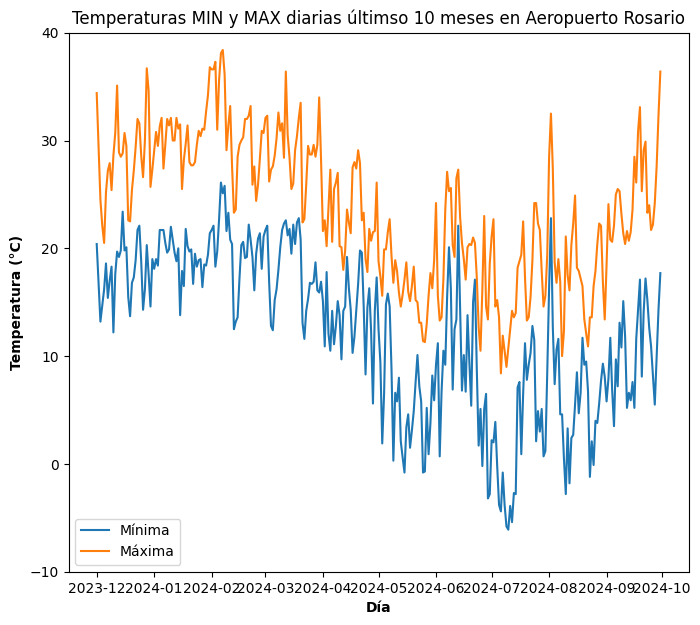

In [106]:
# Nos quedamos con los datos en el rago de fechas (último año)
datos = df[(df['FECHA'] < "2024-10-01") & (df['FECHA'] >= "2023-12-01") \
            & (df['NOMBRE'] == 'ROSARIO AERO')]

plt.figure(figsize = (8,7))

sns.lineplot(x = 'FECHA', y = 'TMIN', data = datos, label='Mínima')
sns.lineplot(x = 'FECHA', y = 'TMAX', data = datos, label='Máxima')

plt.xlabel('Día', fontweight = 'bold')
plt.ylabel('Temperatura (°C)', fontweight = 'bold')

plt.ylim(-10, 40)


plt.title('Temperaturas MIN y MAX diarias últimso 10 meses en Aeropuerto Rosario')

plt.show()

# Item 4

En base a lo realizado en los dos ítems anteriores, responda las siguientes preguntas:

(a) ¿Cuál fue el mes del último año con la mayor temperatura máxima mediana?

(b) ¿Cuál fue el mes del último año con la menor temperatura mínima mediana?

(c) Considerando la variabilidad del 50% central de las temperaturas registradas en el mes, ¿cuál fue el mes del último año con una menor dispersión tanto en sus temperaturas mínimas como en sus temperaturas máximas?

(d) ¿Cuál fue el mes del último año que presentó una mayor amplitud en sus temperaturas mínimas registradas?

(e) Considerando los meses del invierno 2025, ¿existió algún mes en el cual se haya registrado una temperatura máxima atípica en relación al resto de los registros de ese mes?

(a) Enero de 2024

(b) Julio de 2024

In [107]:
# Item (b)

# Agrupamos
grupo = df.groupby(df['FECHA'].dt.to_period('M'))

# Calcular IQR
iqr = grupo[['TMIN', 'TMAX']].agg(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
)

# Mes con menor dispersión
mes_min_tmin = iqr['TMIN'].idxmin()
mes_min_tmax = iqr['TMAX'].idxmin()

print("Menor dispersión TMIN:", mes_min_tmin)
print("Menor dispersión TMAX:", mes_min_tmax)

Menor dispersión TMIN: 2024-01
Menor dispersión TMAX: 2024-01


In [108]:
# Item (d)
# Calculamos el máximo de los rangos de TMIN

amplitud = grupo['TMIN'].agg(
    lambda x: x.max() - x.min()
)

mes_mayor_amplitud = amplitud.idxmax()

print(mes_mayor_amplitud)



2024-08


In [116]:
# Item e
# Vamos a usar el gráfico de caja

datos_invierno = df[(df['FECHA'] >= '2024-07-01') & (df['FECHA'] < '2024-10-01')]
datos_invierno['MES'] = datos_invierno['FECHA'].dt.month

datos_invierno.head()

,FECHA,TMAX,TMIN,NOMBRE,MES
118,2024-09-30,27.6,18.8,AEROPARQUE AERO,9
119,2024-09-30,22.6,12.4,AZUL AERO,9
120,2024-09-30,22.6,11.2,BAHIA BLANCA AERO,9
121,2024-09-30,9.6,2.0,BARILOCHE AERO,9
122,2024-09-30,-9.0,-15.4,BASE BELGRANO II,9


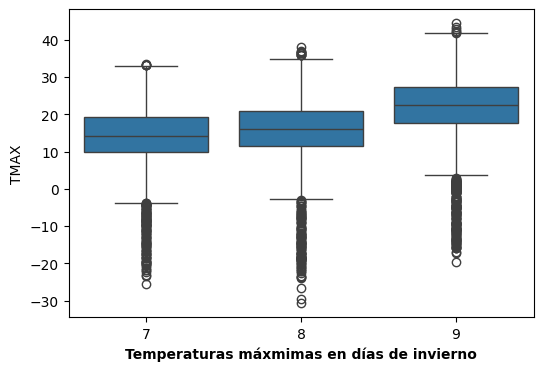

In [118]:
plt.figure(figsize = (6,4))

sns.boxplot(x = 'MES', y="TMAX", data = datos_invierno)
plt.xlabel('Temperaturas máxmimas en días de invierno', fontweight = 'bold')
plt.show()

El mes con la temperatura más atípica es Agosto 2024.

# Item 5 
Realice nuevamente el ítem 3 con los datos correspondientes a la estación meteorológica localizada en la Base Marambio de la Antártida Argentina. Compare los dos gráficos y comente las diferencias que encuentra en las distribuciones de las temperaturas registradas en ambas estaciones.

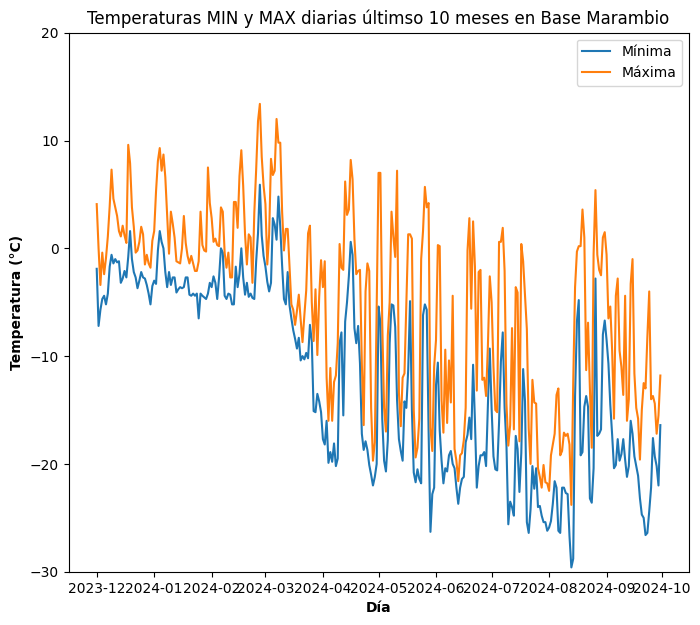

In [125]:
# Nos quedamos con los datos en el rago de fechas (último año)
datos2 = df[(df['FECHA'] < "2024-10-01") & (df['FECHA'] >= "2023-12-01") \
            & (df['NOMBRE'] == 'BASE MARAMBIO')]

plt.figure(figsize = (8,7))

sns.lineplot(x = 'FECHA', y = 'TMIN', data = datos2, label='Mínima')
sns.lineplot(x = 'FECHA', y = 'TMAX', data = datos2, label='Máxima')

plt.xlabel('Día', fontweight = 'bold')
plt.ylabel('Temperatura (°C)', fontweight = 'bold')

plt.ylim(-30, 20)


plt.title('Temperaturas MIN y MAX diarias últimso 10 meses en Base Marambio')

plt.show()

En la Base Marambio hay menos diferencia entre la eemperatura mínima y la máxima pero fluctua más día a día que en Aeropuerto Rosario.